In [18]:
import sys
import os

# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import matplotlib.patches as patches
import torch
import copy
import sys
sys.path.append("/Users/LOCCO_Louise/Documents/Git/code_amaury")
from simu_PSF_polarMFM import *
from extract_experimental_psf import *
from tqdm import tqdm
import time
from torch import nn
from torch.optim import SGD, Adam, AdamW
import torch.nn.functional as F

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using GPU")
else:   
    device = torch.device('cpu')
    print("Using CPU")

Using GPU


In [3]:
d = np.array([1.1643099, 1.4462458, 1.7931267])
d = np.array([np.mean(d)-0.350, np.mean(d), np.mean(d)+0.350])
QE = 0.92
EM = 250
sensitivity = 15.4

In [5]:
Nframe=15
raw = np.zeros((Nframe,6,214,129))

In [6]:
path_info = '\\\\NAS_LOCCO\\Amaury\\DATA\\PolMFM_SilicaBeads_SLB_NR\\image_Pos0_2.ome_results_fr1to8095_method=Propagation matrix_box-method=Fixed_invertRotationPolarizer_corr.csv'

In [7]:
def extract_frames(frame_0, N_frame):
    error_indices = []
    for i in range(N_frame):
        number = str(frame_0 + i).zfill(4)
        print(number)
        path_data = '\\\\NAS_LOCCO\\Amaury\\DATA\\PolMFM_SilicaBeads_SLB_NR\\2024-01-11_SilicaBeads_Lipids_NR\\001_SM_560nm_EM250_25ms\\SilicaBead\\images\\RAW_DATA\\image_Pos0_2_reco\\image_Pos0_2_'+number+'.tif'
        raw_ = extract_raw(path_data)
        if raw_ is None:
            error_indices.append(i)
            continue
        else:
            raw[i] = raw_
        del(raw_)
    return raw, error_indices

def extract_positions(frame_0, N_frame, error_indices):
    index_frame = []
    x, y, z, rho, delta = [], [], [], [], []
    ind = 0
    for i in range(N_frame):
        if i not in error_indices:
            x__, y__, z__, rho__, delta__ = position_from_data(data, frame_0+i)
            x = np.concatenate((x, x__))
            y = np.concatenate((y, y__))
            z = np.concatenate((z, z__))
            rho = np.concatenate((rho, rho__))
            delta = np.concatenate((delta, delta__))
            for k in range(len(x__)):
                index_frame.append(ind)
        ind+=1
    index_frame=np.array(index_frame)
    return x, y, z, rho, delta, index_frame

def limit(x, lim, slope, upper=True):
    '''
    if upper:
       return torch.sum(torch.tensor(1/(1+torch.exp(-slope*(x-lim))), requires_grad=True, device=device))
    else:
        return torch.sum(torch.tensor(1/(1+torch.exp(slope*(x-lim))), requires_grad=True, device=device))
    '''
    if upper:
        return torch.sum(torch.exp((x-lim)*slope))
    else:
        return torch.sum(torch.exp(-1*(x-lim)*slope))
    
def loss_pos(xp, yp, zp, rho, eta, delta, N_photons, data, second_plane, background, sigma, dim_simu, plot):
    u, v, M_ = compute_M(xp=xp, yp=yp, zp=zp, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2
                    , Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                        second_plane=second_plane, polar_projections=polar_projections, N=N,
                    l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG, device=device, polar_offset=0., polar_offset2=0.)
    dim_data = 6
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]
    loss = torch.sum(torch.add(torch.sum(h, dim=2), -(torch.sum(data, dim=2)+sigma**2)*torch.log(torch.sum(h, dim=2)+background+sigma**2)))
    #loss = torch.sum(torch.pow(torch.sum(torch.add(h, -data), dim=(2,)), 2)) 
    x_bound = limit(xp, 5*0.12, 100, upper=True) + limit(xp, -5*0.12, 100, upper=False)
    y_bound = limit(yp, 5*0.12, 100, upper=True) + limit(yp, -5*0.12, 100, upper=False)
    z_bound = limit(zp, 5., 100, upper=True) + limit(zp, 0, 100, upper=False)
    N_bound = torch.sum((N_photons - (torch.sum(data, dim=(1,2,3,4)) - background*len(data[0].flatten())) )**2)
    if plot:
        for nb in range(data.shape[0]):
            if zp[nb].cpu().detach().numpy()>1.5:
                print(zp[nb].cpu().detach().numpy())
                maxi = max(np.max(data[nb,:,:].flatten().cpu().detach().numpy()), np.max(h[nb,:,:].flatten().cpu().detach().numpy()))
                fig, ax = plt.subplots(3)
                ax[0].imshow(data[nb,0,0].cpu().detach().numpy()+data[nb,0,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                ax[0].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                ax[1].imshow(data[nb,1,0].cpu().detach().numpy() + data[nb,1,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                ax[1].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                ax[2].imshow(data[nb,2,0].cpu().detach().numpy()+data[nb,2,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                ax[2].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                #ax[0,1].imshow(data[nb,0,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                #ax[0,1].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                #ax[1,1].imshow(data[nb,1,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                #ax[1,1].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                #ax[2,1].imshow(data[nb,2,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                #ax[2,1].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                plt.show()
                del(fig, ax)
                fig, ax = plt.subplots(3)
                ax[0].imshow(h[nb,0,0].cpu().detach().numpy()+h[nb,0,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                ax[0].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                ax[1].imshow(h[nb,1,0].cpu().detach().numpy() + h[nb,1,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                ax[1].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                ax[2].imshow(h[nb,2,0].cpu().detach().numpy()+h[nb,2,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                ax[2].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                #ax[0,1].imshow(h[nb,0,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                #ax[0,1].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                #ax[1,1].imshow(h[nb,1,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                #ax[1,1].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                #ax[2,1].imshow(h[nb,2,1].cpu().detach().numpy(), vmin=0., vmax=maxi)
                #ax[2,1].scatter(xp[nb].cpu().detach().numpy()/0.120+6, yp[nb].cpu().detach().numpy()/0.120+6, s=10, c='r')
                plt.show()
                del(fig, ax)
    return loss +x_bound+y_bound+z_bound+N_bound*0.1

def loss_angle(M_, rho, eta, delta, N_photons, data, background, sigma, dim_simu):
    dim_data = 6
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]

    loss = torch.sum(torch.add(h, -(data+sigma**2)*torch.log(h+background+sigma**2)))
    #loss = torch.sum(torch.pow(torch.sum(torch.add(h, -data), dim=(2,)), 2)) 
    delta_bound = limit(delta, 180, 100, upper=True) + limit(delta, 1, 100, upper=False)
    N_bound = torch.sum((N_photons - (torch.sum(data, dim=(1,2,3,4)) - background*len(data[0].flatten())) )**2)
    return loss + 1000.*(delta_bound) + N_bound #+ 100000*torch.sum(h**2)

def loss_angle_with_M(polar_proj, polar_proj2, rho, eta, delta, N_photons, x_fine, y_fine, z_fine, zernx, zerny, data, background, sigma, dim_simu, plot):
    dim_data = 6
    u, v, M_ = compute_M(xp=x_fine, yp=y_fine, zp=z_fine, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2
                    , Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_masky=phase_mask, phase_maskx=phase_mask, zernike_base=zernike_base, zernike_coefs_x=torch.reshape(zernx, (3,15)), zernike_coefs_y=torch.reshape(zerny, (3,15)),
                        second_plane=second_plane, polar_projections=polar_projections, N=N,
                    l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG, device=device, polar_offset=polar_proj, polar_offset2=polar_proj2)
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]
    
    loss = torch.sum(torch.add(h, -(data+sigma**2)*torch.log(h+background+sigma**2)))
    #loss = torch.sum(torch.pow(torch.sum(torch.add(h, -data), dim=(2,)), 2)) 
    delta_bound = limit(delta, 180, 100, upper=True) + limit(delta, 1, 100, upper=False)
    N_bound = torch.sum((N_photons - (torch.sum(data, dim=(1,2,3,4)) - background*len(data[0].flatten())) )**2)
    if plot:
        plt.imshow(h[0,0,0].cpu().detach().numpy())
        plt.show()
    return loss + 1000.*(delta_bound) #+ N_bound #+ 100000*torch.sum(h**2)

def score_eval(M_, rho, eta, delta, N_photons, data, background, sigma, dim_simu):
    dim_data = 6
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]
    score = torch.sum(torch.add(h, -(data+sigma**2)*torch.log(h+background+sigma**2)), dim=(1,2,3,4))
    return score.numpy() 

In [19]:
blockA = nn.Sequential(
    nn.BatchNorm2d(6),
          nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
          nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
        nn.MaxPool2d(2),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU()
        ) 

In [38]:
# ---------------------
# Inception-ResNet Block
# ---------------------
class InceptionResNetBlockA(nn.Module):
    def __init__(self):
        super().__init__()

        # Branch 1: 1x1 convolution
        self.branch1 = nn.Sequential(nn.Conv2d(128, 32, kernel_size=1),
        nn.BatchNorm2d(32),
    nn.ReLU())

        # Branch 2: 1x1 + 3x3 convolution
        self.branch2 = nn.Sequential(
            nn.Conv2d(128, 32, kernel_size=1),
            nn.BatchNorm2d(32),
    nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
    nn.ReLU()
        )

        # Branch 3: 
        self.branch3 = nn.Sequential(
            nn.Conv2d(128, 32, kernel_size=1),
            nn.BatchNorm2d(32),
    nn.ReLU(),
            nn.Conv2d(32, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
    nn.ReLU(),
            nn.Conv2d(48, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
    nn.ReLU()
        )

        # Combine branches
        self.conv_linear = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(64)

        self.shortcut = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=1),
            nn.BatchNorm2d(64)
        )

    def forward(self, x):
        residual = self.shortcut(x)
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out3 = self.branch3(x)
        out = torch.cat([out1, out2, out3], dim=1)
        out = self.conv_linear(out)
        out = self.bn(out)
        out += residual  # Residual connection
        return F.relu(out)


In [41]:
resnetA = InceptionResNetBlockA()
backbone = nn.Sequential(blockA,
                      resnetA,
                      nn.MaxPool2d(2),
                      nn.Flatten(),
                      nn.Linear(576, 256),
                      nn.BatchNorm1d(256),
    nn.ReLU(),
                      nn.Dropout(p=0.3),
                    nn.Linear(256, 256),
                         nn.BatchNorm1d(256),
                      nn.ReLU(),
                      nn.Linear(256, 64),
                      nn.BatchNorm1d(64),
    nn.ReLU(),
                     )

In [42]:
model3d = nn.Sequential(backbone,
                      nn.Linear(64, 3),
                       nn.BatchNorm1d(3),
                      nn.Tanh())

In [56]:
model3d.load_state_dict(torch.load("model3d.pth"))
model3d.eval()  
model3d.to(device)

C:\Users\Amaury\AppData\Local\Temp\ipykernel_54072\2106487171.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model3d.load_state_dict(torch.load("model3d.pth"))


Sequential(
  (0): Sequential(
    (0): Sequential(
      (0): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (1): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (9): ReLU()
      (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (12): ReLU()
      (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (14): Conv2d(128,

In [44]:
data = pos_from_csv(path_info)

In [62]:
N_batch = 15
batch_offset = 0

In [63]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [68]:
pred = []
for batch_number in range(N_batch):
    t0 = time.time()
    raw, error_indices = extract_frames((batch_number+batch_offset)*Nframe+1, Nframe)
    x, y, z, rho, delta, index_frame = extract_positions((batch_number+batch_offset)*Nframe+1, Nframe, error_indices)
    raw = raw*sensitivity/(QE*EM)

    sigma = np.std(raw.flatten())
    background = np.mean(raw.flatten())

    nb = len(x)
    for k, ele in enumerate(x):
        if np.isnan(x[nb-1-k]) or np.isnan(y[nb-1-k]) or np.isnan(z[nb-1-k]) or np.isnan(rho[nb-1-k]) or np.isnan(delta[nb-1-k]):
            x = np.delete(x,nb-1-k,0)
            y = np.delete(y,nb-1-k,0)
            z = np.delete(z,nb-1-k,0)
            rho = np.delete(rho,nb-1-k,0)
            delta = np.delete(delta,nb-1-k,0)
            index_frame = np.delete(index_frame,nb-1-k,0)
    
    NPSF = len(x)

    single_psf = extract_raw_xy(raw[0], x[index_frame==0], y[index_frame==0])
    for i in range(1,Nframe):
        single_psf = np.concatenate((single_psf, extract_raw_xy(raw[i], x[index_frame==i], y[index_frame==i])))

    #single_psf = single_psf[:,::-1]

    x_start = torch.tensor([0. for k in range(len(x))], requires_grad=False, device=device)
    y_start = torch.tensor([0. for k in range(len(x))], requires_grad=False, device=device)

    z_exp =  torch.tensor([1.2 for k in range(len(x))], requires_grad=False, device=device) 

    rho_exp = torch.tensor(rho, requires_grad=False, device=device)
    delta_exp = torch.tensor(delta, requires_grad=False, device=device)

    d_ = -torch.tensor([d[1] for k in range(len(x))], requires_grad=False, device=device)
    second_plane = torch.tensor([d[1]-d[0], 0, d[1]-d[2]], device=device)
    polar_projections = np.array([0, 45, 0])

    N=torch.tensor(80, device=device)
    l_pixel=torch.tensor(16, device=device)
    NA=torch.tensor(1.4, device=device)
    mag=torch.tensor(100, device=device)
    lambd=torch.tensor(638, device=device)
    f_tube=torch.tensor(200, device=device)
    MAG=torch.tensor(200/150, device=device)
    xx, yy, th1, phi, [Ex0, Ex1, Ex2], [Ey0, Ey1, Ey2], r, r_cut, k_, f_o = vectorial_BFP_perfect_focus(N, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, device=device)

    if batch_number==0:
        phase_mask = torch.stack([torch.ones((N,N), device=device), torch.ones((N,N), device=device), torch.ones((N,N), device=device)])
        zernike_base = generate_zernike_base(r_cut=r_cut, N=N, zernike_order=4, device=device)
        zernike_coefs_x = torch.zeros((3,15), device=device)
        zernike_coefs_y = torch.zeros((3,15), device=device)
    
    noisy_psf = torch.tensor([single_psf[k] for k in range(len(x))], device=device, dtype=torch.float32)
    noisy_to_model = torch.reshape(noisy_psf, (noisy_psf.shape[0], 6, 13, 13))
    for k in range(noisy_psf.shape[0]):
        pred.append(model3d(noisy_to_model).detach().cpu().numpy()[k])

0001
0002
0003
0004
0005
0006
0007
0008
0009
0010
0011
0012
0013
0014
0015
0016
0017
0018
0019
0020
0021
0022
0023
0024
0025
0026
0027
0028
0029
0030
0031
0032
0033
0034
0035
0036
0037
0038
0039
0040
0041
0042
0043
0044
0045
0046
0047
0048
0049
0050
0051
0052
0053
0054
0055
0056
0057
0058
0059
0060
0061
0062
0063
0064
0065
0066
0067
0068
0069
0070
0071
0072
0073
0074
0075
0076
0077
0078
0079
0080
0081
0082
0083
0084
0085
0086
0087
0088
0089
0090
0091
0092
0093
0094
0095
0096
0097
0098
0099
0100
0101
0102
0103
0104
0105
0106
0107
0108
0109
0110
0111
0112
0113
0114
0115
0116
0117
0118
0119
0120
0121
0122
0123
0124
0125
0126
0127
0128
0129
0130
0131
0132
0133
0134
0135
0136
0137
0138
0139
0140
0141
0142
0143
0144
0145
0146
0147
0148
0149
0150
0151
0152
0153
0154
0155
0156
0157
0158
0159
0160
0161
0162
0163
0164
0165
0166
0167
0168
0169
0170
0171
0172
0173
0174
0175
0176
0177
0178
0179
0180
0181
0182
0183
0184
0185
0186
0187
0188
0189
0190
0191
0192
0193
0194
0195
0196
0197
0198
0199
0200


(array([ 4.,  7.,  7.,  7.,  4., 11., 11.,  9.,  7., 15.,  9.,  8., 10.,
        13.,  7., 11., 21., 14., 15., 14., 17., 17., 12., 17., 27., 19.,
        20., 30., 26., 25., 25., 35., 34., 31., 30., 28., 31., 33., 21.,
        18., 13., 21., 18.,  9.,  6.,  5.,  2.,  5., 11.,  9.,  5.,  9.,
         8.,  9., 12.,  9.,  5., 10.,  7., 12., 20., 29., 28., 26., 17.,
        16., 29., 17., 18., 17., 19., 14., 10., 16., 13., 14.,  8.,  8.,
         5., 14.,  8.,  5., 10.,  3.,  3.,  6.,  6.,  6.,  6.,  0.,  1.,
         5.,  3.,  3.,  3.,  1.,  1.,  3.,  2.,  2.]),
 array([1.03340924, 1.05213022, 1.07085109, 1.08957207, 1.10829306,
        1.12701404, 1.14573491, 1.16445589, 1.18317688, 1.20189774,
        1.22061872, 1.23933971, 1.25806069, 1.27678156, 1.29550254,
        1.31422353, 1.33294439, 1.35166538, 1.37038636, 1.38910723,
        1.40782821, 1.4265492 , 1.44527018, 1.46399105, 1.48271203,
        1.50143301, 1.52015388, 1.53887486, 1.55759585, 1.57631683,
        1.5950377 , 1.6137

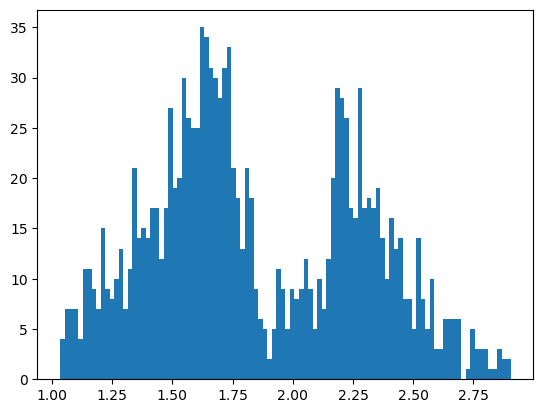

In [70]:
pred = np.array(pred)
plt.hist(2.5*0.8+(1*pred[:,2]), bins=100)